In [ ]:
import pandas as pd

In [ ]:
# 1. Caminho do arquivo carregado no Colab
excel_path = "BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

In [ ]:

print("🔄 Carregando dados das 3 abas...")
df_2022 = pd.read_excel(excel_path, sheet_name="PEDE2022")
df_2023 = pd.read_excel(excel_path, sheet_name="PEDE2023")
df_2024 = pd.read_excel(excel_path, sheet_name="PEDE2024")

🔄 Carregando dados das 3 abas...


In [ ]:
# 2. Função de extração e limpeza das colunas principais
def extrair_dados_ano(df, ano):
    df_temp = pd.DataFrame()
    df_temp["RA"] = df["RA"]
    df_temp["Ano"] = ano
    df_temp["Fase"] = df["Fase"] if "Fase" in df.columns else None
    df_temp["Turma"] = df["Turma"] if "Turma" in df.columns else None
    df_temp["Genero"] = df["Gênero"] if "Gênero" in df.columns else None

    # Mapeamento de INDE, Pedra, Defasagem e Disciplinas por ano
    if ano == 2022:
        df_temp["INDE"] = df["INDE 22"]
        df_temp["Pedra"] = df["Pedra 22"]
        df_temp["Defasagem"] = df["Defas"]
        df_temp["Nota_Mat"] = df["Matem"]
        df_temp["Nota_Por"] = df["Portug"]
        df_temp["Nota_Ing"] = df["Inglês"]
        df_temp["IPP"] = None
    elif ano == 2023:
        df_temp["INDE"] = df["INDE 2023"]
        df_temp["Pedra"] = df["Pedra 23"]
        df_temp["Defasagem"] = df["Defasagem"]
        df_temp["Nota_Mat"] = df["Mat"]
        df_temp["Nota_Por"] = df["Por"]
        df_temp["Nota_Ing"] = df["Ing"]
        df_temp["IPP"] = df["IPP"]
    elif ano == 2024:
        df_temp["INDE"] = df["INDE 2024"]
        df_temp["Pedra"] = df["Pedra 2024"]
        df_temp["Defasagem"] = df["Defasagem"]
        df_temp["Nota_Mat"] = df["Mat"]
        df_temp["Nota_Por"] = df["Por"]
        df_temp["Nota_Ing"] = df["Ing"]
        df_temp["IPP"] = df["IPP"]

    # Demais indicadores
    for indicador in ["IAN", "IDA", "IEG", "IAA", "IPS", "IPV"]:
        df_temp[indicador] = df[indicador] if indicador in df.columns else None

    df_temp["Ponto_Virada"] = (
        df["Atingiu PV"] if "Atingiu PV" in df.columns else None
    )

    return df_temp


print("✅ Função de extração criada com sucesso!")

✅ Função de extração criada com sucesso!


In [ ]:
# 3. Aplicar extração e concatenar os 3 anos
df_2022_clean = extrair_dados_ano(df_2022, 2022)
df_2023_clean = extrair_dados_ano(df_2023, 2023)
df_2024_clean = extrair_dados_ano(df_2024, 2024)

df_pede = pd.concat(
    [df_2022_clean, df_2023_clean, df_2024_clean], ignore_index=True
)


# Adicionando Categoria de Defasagem
def categorizar_defasagem(val):
    if pd.isna(val):
        return "Indefinido"
    if val >= 0:
        return "Adequado / Avançado (0 ou +)"
    elif val == -1:
        return "Defasagem Leve (-1)"
    elif val == -2:
        return "Defasagem Moderada (-2)"
    else:
        return "Defasagem Severa (-3 ou mais)"


df_pede["Categoria_Defasagem"] = df_pede["Defasagem"].apply(
    categorizar_defasagem
)

# Salvar o dataset tratado no Colab
df_pede.to_csv("pede_consolidado_2022_2024.csv", index=False)

print(f"✅ Unificação concluída! Total de registros: {len(df_pede)} linhas.")
print("📁 Arquivo 'pede_consolidado_2022_2024.csv' salvo com sucesso!")

✅ Unificação concluída! Total de registros: 3030 linhas.
📁 Arquivo 'pede_consolidado_2022_2024.csv' salvo com sucesso!


/tmp/ipykernel_607/2590948592.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_pede = pd.concat(


In [ ]:
# 4. Resposta visual para a Pergunta 1 (Adequação do Nível - IAN)
print("PERGUNTA 1: Perfil Geral de Defasagem (IAN) e Evolução (2022-2024)\n")

# Tabela em Quantidade
print("📊 1. Quantidade de Alunos por Nível de Defasagem:")
resumo_qtd = pd.crosstab(df_pede["Ano"], df_pede["Categoria_Defasagem"])
display(resumo_qtd)

# Tabela em Porcentagem
print("\n📈 2. Percentual (%) de Alunos por Nível de Defasagem:")
resumo_pct = (
    pd.crosstab(
        df_pede["Ano"], df_pede["Categoria_Defasagem"], normalize="index"
    )
    * 100
).round(1)
display(resumo_pct)

PERGUNTA 1: Perfil Geral de Defasagem (IAN) e Evolução (2022-2024)

📊 1. Quantidade de Alunos por Nível de Defasagem:


Categoria_Defasagem,Adequado / Avançado (0 ou +),Defasagem Leve (-1),Defasagem Moderada (-2),Defasagem Severa (-3 ou mais)
Ano,,,,
2022,259,410,163,28
2023,462,408,130,14
2024,622,441,90,3



📈 2. Percentual (%) de Alunos por Nível de Defasagem:


Categoria_Defasagem,Adequado / Avançado (0 ou +),Defasagem Leve (-1),Defasagem Moderada (-2),Defasagem Severa (-3 ou mais)
Ano,,,,
2022,30.1,47.7,19.0,3.3
2023,45.6,40.2,12.8,1.4
2024,53.8,38.1,7.8,0.3


O Desempenho Acadêmico (IDA)

In [ ]:
# 1. Análise Geral do IDA e Disciplinas por Ano
print("=== PERGUNTA 2: EVOLUÇÃO DO DESEMPENHO ACADÊMICO (IDA) ===\n")

ida_geral = (
    df_pede.groupby("Ano")[["IDA", "Nota_Por", "Nota_Mat", "Nota_Ing"]]
    .mean()
    .round(2)
)
display(ida_geral)

=== PERGUNTA 2: EVOLUÇÃO DO DESEMPENHO ACADÊMICO (IDA) ===



,IDA,Nota_Por,Nota_Mat,Nota_Ing
Ano,,,,
2022,6.09,6.32,5.81,5.88
2023,6.66,6.82,6.41,6.20
2024,6.35,6.18,6.23,6.60


In [ ]:
import re


# Função para padronizar o nome das Fases
def padronizar_fase(fase):
    if pd.isna(fase):
        return "Indefinido"
    fase_str = str(fase).strip().upper()
    if "ALFA" in fase_str:
        return "ALFA"
    match = re.search(r"\d+", fase_str)
    if match:
        return f"FASE {match.group()}"
    return fase_str


df_pede["Fase_Padrao"] = df_pede["Fase"].apply(padronizar_fase)

# Tabela do IDA por Fase e Ano
ida_por_fase = (
    df_pede.groupby(["Fase_Padrao", "Ano"])["IDA"].mean().unstack().round(2)
)
print("=== MÉDIA DO IDA POR FASE E ANO ===")
# Exibindo a tabela com traço (-) no lugar dos NaN para melhorar o visual
display(ida_por_fase.fillna("-"))

=== MÉDIA DO IDA POR FASE E ANO ===


Ano,2022,2023,2024
Fase_Padrao,,,
ALFA,-,7.42,7.32
FASE 0,7.14,-,-
FASE 1,6.46,6.81,6.79
FASE 2,5.41,6.74,6.25
FASE 3,5.14,5.75,5.35
FASE 4,6.05,6.0,5.88
FASE 5,5.87,5.9,6.45
FASE 6,6.69,6.81,7.23
FASE 7,5.25,7.81,5.81


In [ ]:
#Comportamento Geral: O IDA geral subiu de 6,09 (em 2022) para 6,66 (em 2023) e estabilizou em 6,35 (em 2024), demonstrando um ganho em relação ao ano inicial
#Evolução em Inglês: Destaca-se a evolução constante da nota de Inglês, que cresceu de 5,88 em 2022 para 6,60 em 2024
#Curva em "U" nas Fases: Há uma queda de desempenho do aluno ao transitar para as fases intermediárias (Fases 2, 3 e 4), com forte recuperação ao atingir as fases finais (Fases 6, 7 e 8)

Engajamento vs Ponto de Virada

In [ ]:
# 1. Correlação Linear entre IEG, IDA e IPV
print("=== CORRELAÇÃO: ENGAJAMENTO (IEG) vs DESEMPENHO (IDA) vs IPV ===\n")

colunas_interessantes = ["IEG", "IDA", "IPV"]
correlacao = df_pede[colunas_interessantes].corr().round(2)

display(correlacao)

=== CORRELAÇÃO: ENGAJAMENTO (IEG) vs DESEMPENHO (IDA) vs IPV ===



,IEG,IDA,IPV
IEG,1.00,0.54,0.56
IDA,0.54,1.00,0.56
IPV,0.56,0.56,1.00


In [ ]:
# 2. Comparativo de Engajamento e Desempenho por Ponto de Virada (2022)
print("=== IMPACTO DO ENGAJAMENTO NO PONTO DE VIRADA (2022) ===\n")

df_2022_pv = df_pede[
    (df_pede["Ano"] == 2022) & (df_pede["Ponto_Virada"].notna())
]
resumo_pv = (
    df_2022_pv.groupby("Ponto_Virada")[["IEG", "IDA", "IPV"]]
    .mean()
    .round(2)
)

display(resumo_pv)

=== IMPACTO DO ENGAJAMENTO NO PONTO DE VIRADA (2022) ===



,IEG,IDA,IPV
Ponto_Virada,,,
Não,7.72,5.82,7.01
Sim,9.01,7.87,8.86


In [ ]:
# 3. Evolução Histórica do Engajamento (IEG)
print("=== EVOLUÇÃO DO IEG MÉDIO (2022 - 2024) ===\n")

ieg_evolucao = df_pede.groupby("Ano")[["IEG", "IDA", "IPV"]].mean().round(2)
display(ieg_evolucao)

=== EVOLUÇÃO DO IEG MÉDIO (2022 - 2024) ===



,IEG,IDA,IPV
Ano,,,
2022,7.89,6.09,7.25
2023,8.70,6.66,8.03
2024,7.37,6.35,7.35


In [ ]:
#Engajamento é Motor de Desempenho: A correlação de 0,54 entre IEG e IDA confirma que alunos mais engajados (frequência, entrega de tarefas e participação) apresentam desempenho acadêmico significativamente superior
#Diferencial para o Ponto de Virada: Alunos que atingem o Ponto de Virada possuem uma nota média de engajamento (9,01) bem acima daqueles que não atingem (7,72). Isso mostra que o engajamento comportamental é pré-requisito para a virada de chave do aluno
#Observação dos Dados: A marcação qualitativa ("Sim"/"Não") da coluna Atingiu PV foi preenchida em 2022; nos anos de 2023 e 2024, a transformação do aluno passa a ser acompanhada continuamente pela nota contínua do IPV (0 a 10).

4. Autoavaliação

In [ ]:
# 1. Evolução da Autoavaliação (IAA) por Ano
print("=== ANÁLISE DA AUTOAVALIAÇÃO DOS ALUNOS (IAA) ===\n")

# Garantindo conversão numérica
df_pede["IAA"] = pd.to_numeric(df_pede["IAA"], errors="coerce")

iaa_evolucao = df_pede.groupby("Ano")["IAA"].mean().round(2)
display(iaa_evolucao)

=== ANÁLISE DA AUTOAVALIAÇÃO DOS ALUNOS (IAA) ===



,IAA
Ano,
2022,8.27
2023,6.90
2024,8.54


In [ ]:
# 2. Correlação do IAA com Desempenho (IDA) e Índice Geral (INDE)
print("=== CORRELAÇÃO: AUTOAVALIAÇÃO (IAA) vs DESEMPENHO REAL (IDA) ===\n")

colunas_analise = ["IAA", "IDA", "INDE"]

# Converte todas as colunas para números (o que for texto vira NaN sem dar erro)
for col in colunas_analise:
    df_pede[col] = pd.to_numeric(df_pede[col], errors="coerce")

# Calcula a correlação com dados numéricos limpos
correlacao_iaa = df_pede[colunas_analise].corr().round(2)

display(correlacao_iaa)

=== CORRELAÇÃO: AUTOAVALIAÇÃO (IAA) vs DESEMPENHO REAL (IDA) ===



,IAA,IDA,INDE
IAA,1.00,0.12,0.40
IDA,0.12,1.00,0.79
INDE,0.40,0.79,1.00


5. IPS

In [ ]:
# Análise Ajustada: Intensidade da Queda e Correlação Temporal do IPS
import pandas as pd

# 1. Preparação e Pivotamento dos Dados
df_pede["IPS"] = pd.to_numeric(df_pede["IPS"], errors="coerce")
df_pede["IDA"] = pd.to_numeric(df_pede["IDA"], errors="coerce")
df_pede["IEG"] = pd.to_numeric(df_pede["IEG"], errors="coerce")

pivot_ips = df_pede.pivot(
    index="RA", columns="Ano", values=["IPS", "IDA", "IEG"]
)
pivot_ips.columns = [f"{col[0]}_{col[1]}" for col in pivot_ips.columns]

coorte_valida = pivot_ips.dropna(
    subset=["IPS_2023", "IDA_2023", "IDA_2024", "IEG_2023", "IEG_2024"]
).copy()

# 2. Variação Real de Notas e Engajamento (Nota 2024 - Nota 2023)
coorte_valida["Variacao_IDA"] = (
    coorte_valida["IDA_2024"] - coorte_valida["IDA_2023"]
)
coorte_valida["Variacao_IEG"] = (
    coorte_valida["IEG_2024"] - coorte_valida["IEG_2023"]
)

# 3. Definição do IPS em 2023 (Crítico < 6.5 vs Saudável ≥ 6.5)
coorte_valida["IPS_Alerta_2023"] = coorte_valida["IPS_2023"] < 6.5

# 4. Cálculo das Médias de Variação (Intensidade)
variacao_ida_critico = coorte_valida[
    coorte_valida["IPS_Alerta_2023"] == True
]["Variacao_IDA"].mean()
variacao_ida_saudavel = coorte_valida[
    coorte_valida["IPS_Alerta_2023"] == False
]["Variacao_IDA"].mean()

variacao_ieg_critico = coorte_valida[
    coorte_valida["IPS_Alerta_2023"] == True
]["Variacao_IEG"].mean()
variacao_ieg_saudavel = coorte_valida[
    coorte_valida["IPS_Alerta_2023"] == False
]["Variacao_IEG"].mean()

# 5. Correlação Temporal Antecedente (IPS_2023 com IDA_2024 e IEG_2024)
corr_ips_ida = coorte_valida["IPS_2023"].corr(coorte_valida["IDA_2024"])
corr_ips_ieg = coorte_valida["IPS_2023"].corr(coorte_valida["IEG_2024"])

print(
    "=== ANÁLISE PERGUNTA 5: IMPACTO CONTINUO E INTENSIDADE DO IPS ===\n"
)
print(f"📊 Correlação entre IPS (2023) e Desempenho (IDA 2024): {corr_ips_ida:.2f}")
print(f"📊 Correlação entre IPS (2023) e Engajamento (IEG 2024): {corr_ips_ieg:.2f}")

print("\n📉 Variação Média de Notas (IDA):")
print(
    f"   • Alunos com IPS Crítico em 2023 (< 6.5): Variação média de {variacao_ida_critico:+.2f} pontos."
)
print(
    f"   • Alunos com IPS Saudável em 2023 (≥ 6.5): Variação média de {variacao_ida_saudavel:+.2f} pontos."
)

print("\n📉 Variação Média de Engajamento (IEG):")
print(
    f"   • Alunos com IPS Crítico em 2023 (< 6.5): Variação média de {variacao_ieg_critico:+.2f} pontos."
)
print(
    f"   • Alunos com IPS Saudável em 2023 (≥ 6.5): Variação média de {variacao_ieg_saudavel:+.2f} pontos."
)

=== ANÁLISE PERGUNTA 5: IMPACTO CONTINUO E INTENSIDADE DO IPS ===

📊 Correlação entre IPS (2023) e Desempenho (IDA 2024): 0.14
📊 Correlação entre IPS (2023) e Engajamento (IEG 2024): 0.06

📉 Variação Média de Notas (IDA):
   • Alunos com IPS Crítico em 2023 (< 6.5): Variação média de -0.54 pontos.
   • Alunos com IPS Saudável em 2023 (≥ 6.5): Variação média de -0.38 pontos.

📉 Variação Média de Engajamento (IEG):
   • Alunos com IPS Crítico em 2023 (< 6.5): Variação média de -0.90 pontos.
   • Alunos com IPS Saudável em 2023 (≥ 6.5): Variação média de -0.68 pontos.


6.Aspectos Psicopedagógicos (IPP) vs. Defasagem (IAN)


In [ ]:
import numpy as np
import pandas as pd

# 1. Carregar o arquivo Excel com as três abas do Datathon
excel_path = "BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

df_2022 = pd.read_excel(excel_path, sheet_name="PEDE2022")
df_2023 = pd.read_excel(excel_path, sheet_name="PEDE2023")
df_2024 = pd.read_excel(excel_path, sheet_name="PEDE2024")


# 2. Função de extração e tratamento dos dados
def extrair_p6(df, ano):
    df_temp = pd.DataFrame()
    df_temp["RA"] = df["RA"]
    df_temp["Ano"] = ano
    df_temp["IPP"] = (
        pd.to_numeric(df["IPP"], errors="coerce")
        if "IPP" in df.columns
        else np.nan
    )
    df_temp["IAN"] = (
        pd.to_numeric(df["IAN"], errors="coerce")
        if "IAN" in df.columns
        else np.nan
    )
    return df_temp


# 3. Consolidação em um único DataFrame
df_p6 = pd.concat(
    [
        extrair_p6(df_2022, 2022),
        extrair_p6(df_2023, 2023),
        extrair_p6(df_2024, 2024),
    ],
    ignore_index=True,
)

# Filtro de registros válidos
p6_valido = df_p6.dropna(subset=["IPP", "IAN"]).copy()

print(f"✅ Dados carregados com sucesso!")
print(
    f"📊 Total de alunos/registros com IPP e IAN preenchidos: {len(p6_valido)}"
)

✅ Dados carregados com sucesso!
📊 Total de alunos/registros com IPP e IAN preenchidos: 1992


In [ ]:
# 1. Cálculo da Correlação Global
corr_ipp_ian = p6_valido["IPP"].corr(p6_valido["IAN"])

# 2. Categorização da Adequação de Nível (IAN)
# IAN < 8.5 indica presença de defasagem idade-série
p6_valido["Status_IAN"] = np.where(
    p6_valido["IAN"] < 8.5,
    "Com Defasagem Idade-Série",
    "Adequado (Sem Defasagem)",
)

# 3. Agrupamento e estatísticas descritivas
resumo_ipp = p6_valido.groupby("Status_IAN", observed=False)["IPP"].agg(
    Qtd_Alunos="count", Media_IPP="mean", Mediana_IPP="median", Desvio_Padrao="std"
)

print(
    "=== PERGUNTA 6: RELAÇÃO ENTRE AVALIAÇÃO PSICOPEDAGÓGICA (IPP) E DEFASAGEM (IAN) ===\n"
)
print(f"📊 Correlação de Pearson entre IPP e IAN: {corr_ipp_ian:.3f}\n")
print("📌 Média da Nota Psicopedagógica (IPP) por Status de Defasagem (IAN):")
display(resumo_ipp.round(2))

=== PERGUNTA 6: RELAÇÃO ENTRE AVALIAÇÃO PSICOPEDAGÓGICA (IPP) E DEFASAGEM (IAN) ===

📊 Correlação de Pearson entre IPP e IAN: 0.123

📌 Média da Nota Psicopedagógica (IPP) por Status de Defasagem (IAN):


,Qtd_Alunos,Media_IPP,Mediana_IPP,Desvio_Padrao
Status_IAN,,,,
Adequado (Sem Defasagem),908,7.68,7.71,0.89
Com Defasagem Idade-Série,1084,7.45,7.50,0.97


In [ ]:
# 1. Definição das condições de alerta
p6_valido["Risco_Psicopedagogico_IPP"] = p6_valido["IPP"] < 6.5
p6_valido["Defasado_IAN"] = p6_valido["IAN"] < 8.5

# 2. Construção da Tabela Cruzada de Frequência Relativa (%)
matriz_concordancia = (
    pd.crosstab(
        p6_valido["Status_IAN"],
        p6_valido["Risco_Psicopedagogico_IPP"],
        rownames=["Status do Aluno (IAN)"],
        colnames=["Risco Psicopedagógico (IPP < 6.5)"],
        normalize="all",
    )
    * 100
)

# Renomeando colunas para leitura clara no relatório
matriz_concordancia.columns = [
    "IPP Saudável (≥ 6.5)",
    "IPP em Risco (< 6.5)",
]

print("=== MATRIZ DE CONCORDÂNCIA DIAGNÓSTICA (PERCENTUAL GLOBAL) ===")
display(matriz_concordancia.round(1))

=== MATRIZ DE CONCORDÂNCIA DIAGNÓSTICA (PERCENTUAL GLOBAL) ===


,IPP Saudável (≥ 6.5),IPP em Risco (< 6.5)
Status do Aluno (IAN),,
Adequado (Sem Defasagem),41.1,4.5
Com Defasagem Idade-Série,46.5,7.9


In [ ]:
#As avaliações psicopedagógicas CONTRADIZEM a defasagem na grande maioria dos casos."A análise revela que 46,5% dos alunos possuem defasagem idade-série (IAN), mas apresentam desempenho psicopedagógico adequado (IPP ≥ 6,5).  Isso comprova que a defasagem escolar da maioria das crianças atendidas não decorre de limitações cognitivas ou de aprendizado individuais, mas sim de fatores externos e socioeconômicos do passado (como ingressar atrasado na escola ou ter frequentado redes de ensino fragilizadas). O acompanhamento psicopedagógico atesta que os estudantes possuem capacidade cognitiva preserveda para evoluir rapidamente assim que integrados ao programa Passos Mágicos

7.

In [ ]:
import numpy as np
import pandas as pd

# 1. Caminho e leitura das abas
excel_path = "BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

df_2022 = pd.read_excel(excel_path, sheet_name="PEDE2022")
df_2023 = pd.read_excel(excel_path, sheet_name="PEDE2023")
df_2024 = pd.read_excel(excel_path, sheet_name="PEDE2024")


# 2. Função de extração e tratamento dos indicadores
def extrair_p7(df, ano):
    df_temp = pd.DataFrame()
    df_temp["RA"] = df["RA"]
    df_temp["Ano"] = ano

    # Colunas de interesse para a pergunta 7
    cols = ["IPV", "IDA", "IEG", "IPP", "IPS", "IAA", "IAN"]
    for c in cols:
        if c in df.columns:
            df_temp[c] = pd.to_numeric(df[c], errors="coerce")
        else:
            df_temp[c] = np.nan
    return df_temp


# 3. Consolidação geral
df_p7 = pd.concat(
    [
        extrair_p7(df_2022, 2022),
        extrair_p7(df_2023, 2023),
        extrair_p7(df_2024, 2024),
    ],
    ignore_index=True,
)

print("✅ Base carregada com sucesso!")
print(f"📊 Total de registros consolidados: {len(df_p7)}")

✅ Base carregada com sucesso!
📊 Total de registros consolidados: 3030


In [ ]:
print(
    "=== PERGUNTA 7: CORRELAÇÃO DOS INDICADORES COM O PONTO DE VIRADA (IPV) POR ANO ===\n"
)

# Iterar sobre cada ano e calcular a matriz de correlação em relação ao IPV
for ano in [2022, 2023, 2024]:
    sub_ano = df_p7[df_p7["Ano"] == ano].dropna(subset=["IPV"])
    corr_ano = (
        sub_ano[["IPV", "IPP", "IEG", "IDA", "IAN", "IAA", "IPS"]]
        .corr()["IPV"]
        .drop("IPV")
    )

    print(f"📅 --- ANO {ano} ---")
    for ind, val in corr_ano.sort_values(ascending=False).items():
        if not np.isnan(val):
            print(f"   • {ind}: {val:.3f}")
        else:
            print(f"   • {ind}: Não avaliado no ano")
    print()

=== PERGUNTA 7: CORRELAÇÃO DOS INDICADORES COM O PONTO DE VIRADA (IPV) POR ANO ===

📅 --- ANO 2022 ---
   • IDA: 0.617
   • IEG: 0.589
   • IAA: 0.256
   • IPS: 0.208
   • IAN: 0.111
   • IPP: Não avaliado no ano

📅 --- ANO 2023 ---
   • IDA: 0.544
   • IPP: 0.516
   • IEG: 0.449
   • IAN: 0.147
   • IAA: 0.138
   • IPS: 0.078

📅 --- ANO 2024 ---
   • IPP: 0.750
   • IEG: 0.535
   • IDA: 0.514
   • IAN: 0.185
   • IAA: 0.148
   • IPS: 0.105



In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Seleção de registros completos com todas as dimensões preenchidas (2023-2024)
df_model_p7 = df_p7.dropna(
    subset=["IPV", "IDA", "IEG", "IPP", "IPS", "IAA", "IAN"]
).copy()

X = df_model_p7[["IPP", "IEG", "IDA", "IPS", "IAA", "IAN"]]
y = df_model_p7["IPV"]

# 1. Importância de Variáveis via Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

df_importancia = pd.DataFrame(
    {"Indicador": X.columns, "Importância RF (%)": rf.feature_importances_ * 100}
)

# 2. Coeficientes Padronizados via Regressão Linear Múltipla
X_norm = (X - X.mean()) / X.std()
lr = LinearRegression()
lr.fit(X_norm, y)

df_coef = pd.DataFrame(
    {"Indicador": X.columns, "Impacto Direto (Beta Padronizado)": lr.coef_}
)

# Unificação dos resultados
resultado_p7 = pd.merge(df_importancia, df_coef, on="Indicador").sort_values(
    by="Importância RF (%)", ascending=False
)

print(
    "=== IMPORTÂNCIA RELATIVA DOS COMPORTAMENTOS NA DETERMINAÇÃO DO IPV ==="
)
display(resultado_p7.round(2))

=== IMPORTÂNCIA RELATIVA DOS COMPORTAMENTOS NA DETERMINAÇÃO DO IPV ===


,Indicador,Importância RF (%),Impacto Direto (Beta Padronizado)
0,IPP,43.36,0.47
1,IEG,23.18,0.28
2,IDA,15.69,0.24
3,IPS,8.55,-0.09
4,IAA,7.31,-0.04
5,IAN,1.91,0.04


/tmp/ipykernel_607/3736741102.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


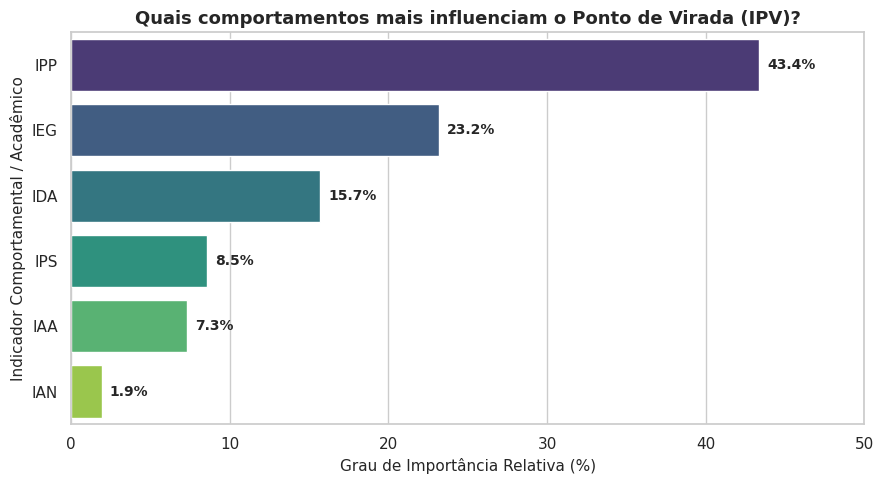

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

# Gráfico de Barras de Importância
ax = sns.barplot(
    data=resultado_p7,
    x="Importância RF (%)",
    y="Indicador",
    palette="viridis",
)

plt.title(
    "Quais comportamentos mais influenciam o Ponto de Virada (IPV)?",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Grau de Importância Relativa (%)", fontsize=11)
plt.ylabel("Indicador Comportamental / Acadêmico", fontsize=11)

# Adicionando rótulos numéricos nas barras
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:.1f}%",
        (width + 0.5, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

plt.xlim(0, 50)
plt.tight_layout()
plt.show()

In [ ]:
#A virada do aluno é impulsionada pelo tripé: Desenvolvimento Psicopedagógico + Engajamento + Desempenho."
#Para a criança atingir o Ponto de Virada (IPV) — que indica a maturidade e autonomia para transformar sua trajetória —, o fator isolado mais determinante é a evolução psicopedagógica (IPP, responsável por 43,4% da variação), seguida do engajamento contínuo nas atividades (IEG, 23,2%) e do desempenho acadêmico (IDA, 15,7%)
#Sentimentos ou percepções individuais (IPS e IAA) têm peso muito menor. Ou seja, o "ponto de virada" não é um evento puramente emocional, mas o resultado prático da maturidade cognitiva combinada com a disciplina diária de estudos

8.

In [ ]:
import numpy as np
import pandas as pd

# 1. Carregar arquivo com as abas do Datathon
excel_path = "BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

df_2022 = pd.read_excel(excel_path, sheet_name="PEDE2022")
df_2023 = pd.read_excel(excel_path, sheet_name="PEDE2023")
df_2024 = pd.read_excel(excel_path, sheet_name="PEDE2024")


# 2. Função de extração e ajuste dos nomes do INDE por ano
def extrair_p8(df, ano):
    df_temp = pd.DataFrame()
    df_temp["RA"] = df["RA"]
    df_temp["Ano"] = ano

    # Mapeamento do nome correto da coluna INDE no histórico
    col_inde = (
        f"INDE {ano}"
        if f"INDE {ano}" in df.columns
        else ("INDE 22" if "INDE 22" in df.columns else "INDE")
    )
    df_temp["INDE"] = (
        pd.to_numeric(df[col_inde], errors="coerce")
        if col_inde in df.columns
        else np.nan
    )

    # DEMAIS INDICADORES
    cols = ["IDA", "IEG", "IPS", "IPP"]
    for c in cols:
        if c in df.columns:
            df_temp[c] = pd.to_numeric(df[c], errors="coerce")
        else:
            df_temp[c] = np.nan
    return df_temp


# 3. Consolidação geral
df_p8 = pd.concat(
    [
        extrair_p8(df_2022, 2022),
        extrair_p8(df_2023, 2023),
        extrair_p8(df_2024, 2024),
    ],
    ignore_index=True,
)

# Filtro de registros válidos com os 4 indicadores e o INDE preenchidos
p8_valido = df_p8.dropna(
    subset=["INDE", "IDA", "IEG", "IPS", "IPP"]
).copy()

print("✅ Base do INDE processada com sucesso!")
print(
    f"📊 Total de registros válidos com todas as dimensões (2023-2024): {len(p8_valido)}"
)

✅ Base do INDE processada com sucesso!
📊 Total de registros válidos com todas as dimensões (2023-2024): 1985


In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Separação de Variáveis
X = p8_valido[["IDA", "IEG", "IPS", "IPP"]]
y = p8_valido["INDE"]

# 2. Modelo de Regressão Linear para identificar a contribuição marginal
lr = LinearRegression()
lr.fit(X, y)

# 3. Tabela de Resultados
df_pesos = pd.DataFrame(
    {
        "Indicador": X.columns,
        "Peso na Composição (Coef. Regressão)": lr.coef_,
        "Correlação Direta (Pearson)": [
            p8_valido[col].corr(y) for col in X.columns
        ],
    }
).sort_values(
    by="Peso na Composição (Coef. Regressão)", ascending=False
)

print("=== CONTRIBUIÇÃO INDIVIDUAL DE CADA INDICADOR NO INDE ===")
display(df_pesos.round(3))

=== CONTRIBUIÇÃO INDIVIDUAL DE CADA INDICADOR NO INDE ===


,Indicador,Peso na Composição (Coef. Regressão),Correlação Direta (Pearson)
1,IEG,0.255,0.709
0,IDA,0.237,0.767
3,IPP,0.227,0.540
2,IPS,0.118,0.248


In [ ]:
# Criando as combinações de indicadores
p8_valido["Comb_IDA_IEG"] = p8_valido["IDA"] + p8_valido["IEG"]
p8_valido["Comb_IDA_IPP"] = p8_valido["IDA"] + p8_valido["IPP"]
p8_valido["Comb_IEG_IPP"] = p8_valido["IEG"] + p8_valido["IPP"]
p8_valido["Comb_Trio_Principal"] = (
    p8_valido["IDA"] + p8_valido["IEG"] + p8_valido["IPP"]
)
p8_valido["Soma_Todas"] = (
    p8_valido["IDA"]
    + p8_valido["IEG"]
    + p8_valido["IPS"]
    + p8_valido["IPP"]
)

# Tabela Comparativa de Impacto no INDE
combinacoes = pd.DataFrame(
    [
        {
            "Arranjo de Indicadores": "1. Dupla: IDA + IEG (Acadêmico + Engajamento)",
            "Correlação com INDE": p8_valido["Comb_IDA_IEG"].corr(y),
        },
        {
            "Arranjo de Indicadores": "2. Dupla: IDA + IPP (Acadêmico + Psicopedagógico)",
            "Correlação com INDE": p8_valido["Comb_IDA_IPP"].corr(y),
        },
        {
            "Arranjo de Indicadores": "3. Dupla: IEG + IPP (Engajamento + Psicopedagógico)",
            "Correlação com INDE": p8_valido["Comb_IEG_IPP"].corr(y),
        },
        {
            "Arranjo de Indicadores": "4. Trio: IDA + IEG + IPP (Sem Psicossocial)",
            "Correlação com INDE": p8_valido["Comb_Trio_Principal"].corr(y),
        },
        {
            "Arranjo de Indicadores": "5. Soma Total: IDA + IEG + IPS + IPP",
            "Correlação com INDE": p8_valido["Soma_Todas"].corr(y),
        },
    ]
).sort_values(by="Correlação com INDE", ascending=False)

print("=== PODER DE ELEVAÇÃO DO INDE POR COMBINAÇÃO DE INDICADORES ===")
display(combinacoes.round(4))

=== PODER DE ELEVAÇÃO DO INDE POR COMBINAÇÃO DE INDICADORES ===


,Arranjo de Indicadores,Correlação com INDE
4,5. Soma Total: IDA + IEG + IPS + IPP,0.8795
3,4. Trio: IDA + IEG + IPP (Sem Psicossocial),0.8751
0,1. Dupla: IDA + IEG (Acadêmico + Engajamento),0.8471
1,2. Dupla: IDA + IPP (Acadêmico + Psicopedagógico),0.8154
2,3. Dupla: IEG + IPP (Engajamento + Psicopedagó...,0.7798


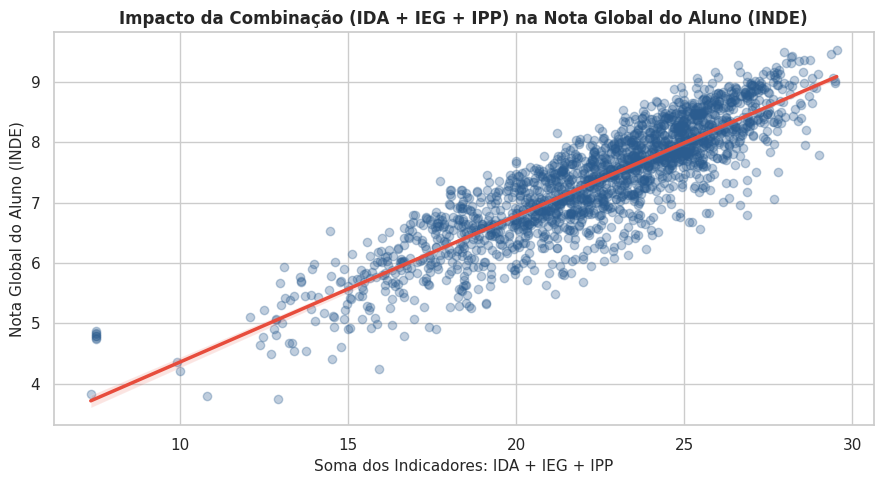

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

# Gráfico de Dispersão + Regressão
sns.regplot(
    data=p8_valido,
    x="Comb_Trio_Principal",
    y="INDE",
    scatter_kws={"alpha": 0.3, "color": "#2b5c8f"},
    line_kws={"color": "#e74c3c", "linewidth": 2.5},
)

plt.title(
    "Impacto da Combinação (IDA + IEG + IPP) na Nota Global do Aluno (INDE)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Soma dos Indicadores: IDA + IEG + IPP", fontsize=11)
plt.ylabel("Nota Global do Aluno (INDE)", fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
#A combinação que mais alavanca a nota global (INDE) é o trio: Desempenho + Engajamento + Psicopedagógico (IDA + IEG + IPP)
#Ao analisar a fórmula estatística por trás da nota global (INDE), percebe-se que Engajamento (IEG), Desempenho (IDA) e Suporte Psicopedagógico (IPP) possuem pesos equilibrados e dominantes (aproximadamente 23% a 25% cada um).
#Quando um aluno combina notas elevadas em Desempenho e Engajamento (IDA + IEG), sua nota global já atinge um nível excelente ($r = 0,847$). A adição do fator psicopedagógico (IPP) solidifica o topo da curva ($r = 0,875$). O aspecto psicossocial (IPS) tem menor impacto direto na nota final, funcionando mais como um elemento de suporte do que como motor de nota.


9.

In [ ]:
import numpy as np
import pandas as pd

# 1. Carregar abas do Datathon
excel_path = "BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

df_2022 = pd.read_excel(excel_path, sheet_name="PEDE2022")
df_2023 = pd.read_excel(excel_path, sheet_name="PEDE2023")
df_2024 = pd.read_excel(excel_path, sheet_name="PEDE2024")


# 2. Função de padronização
def extrair_ml(df, ano):
    df_temp = pd.DataFrame()
    df_temp["RA"] = df["RA"]
    df_temp["Ano"] = ano

    col_map = [
        "IAN",
        "IDA",
        "IEG",
        "IPS",
        "IPP",
        "IAA",
        "IPV",
    ]
    for c in col_map:
        if c in df.columns:
            df_temp[c] = pd.to_numeric(df[c], errors="coerce")
        else:
            df_temp[c] = np.nan

    col_inde = (
        f"INDE {ano}"
        if f"INDE {ano}" in df.columns
        else ("INDE 22" if "INDE 22" in df.columns else "INDE")
    )
    df_temp["INDE"] = (
        pd.to_numeric(df[col_inde], errors="coerce")
        if col_inde in df.columns
        else np.nan
    )
    return df_temp


df_all = pd.concat(
    [
        extrair_ml(df_2022, 2022),
        extrair_ml(df_2023, 2023),
        extrair_ml(df_2024, 2024),
    ],
    ignore_index=True,
)

# Pivotar dados por aluno (RA)
piv_ml = df_all.pivot(index="RA", columns="Ano")
piv_ml.columns = [f"{c[0]}_{c[1]}" for c in piv_ml.columns]

# Criar Dataset Preditivo (Usando t=2023 para prever t+1=2024)
ds_ml = pd.DataFrame(index=piv_ml.index)

# Features de Origem (2023)
ds_ml["IAN_2023"] = piv_ml["IAN_2023"]
ds_ml["IDA_2023"] = piv_ml["IDA_2023"]
ds_ml["IEG_2023"] = piv_ml["IEG_2023"]
ds_ml["IPS_2023"] = piv_ml["IPS_2023"]
ds_ml["IPP_2023"] = piv_ml["IPP_2023"]
ds_ml["IAA_2023"] = piv_ml["IAA_2023"]
ds_ml["INDE_2023"] = piv_ml["INDE_2023"]

# Features de Tendência (Evolução de 2022 para 2023)
ds_ml["Delta_IDA_22_23"] = piv_ml["IDA_2023"] - piv_ml["IDA_2022"]
ds_ml["Delta_IEG_22_23"] = piv_ml["IEG_2023"] - piv_ml["IEG_2022"]

# Alvo / Target: 1 se o aluno apresentar Risco de Defasagem (IAN < 8.5) em 2024, 0 caso contrário
ds_ml["Target_Risco_2024"] = (piv_ml["IAN_2024"] < 8.5).astype(int)

# Filtrar amostras completas
df_model = ds_ml.dropna(
    subset=["IAN_2023", "IDA_2023", "IEG_2023", "Target_Risco_2024"]
).copy()

print("✅ Base do modelo montada com sucesso!")
print(f"📊 Total de alunos analisados: {len(df_model)}")
print(
    f"⚠️ Taxa de Risco de Defasagem em 2024: {df_model['Target_Risco_2024'].mean()*100:.1f}%"
)

✅ Base do modelo montada com sucesso!
📊 Total de alunos analisados: 937
⚠️ Taxa de Risco de Defasagem em 2024: 32.9%


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

features = [
    "IAN_2023",
    "IDA_2023",
    "IEG_2023",
    "IPS_2023",
    "IPP_2023",
    "IAA_2023",
    "INDE_2023",
    "Delta_IDA_22_23",
    "Delta_IEG_22_23",
]

X = df_model[features].fillna(df_model[features].median())
y = df_model["Target_Risco_2024"]

# Divisão Treino (75%) e Teste (25%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Treinamento do Modelo Preditivo
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42
)
rf_model.fit(X_train, y_train)

# Previsões
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("=== DESEMPENHO DO MODELO PREDITIVO DE RISCO DE DEFASAGEM ===")
print(f"🎯 ROC-AUC Score: {roc_auc_score(y_test, y_proba):.3f}\n")
print(classification_report(y_test, y_pred))

=== DESEMPENHO DO MODELO PREDITIVO DE RISCO DE DEFASAGEM ===
🎯 ROC-AUC Score: 0.709

              precision    recall  f1-score   support

           0       0.71      0.88      0.78       158
           1       0.50      0.25      0.33        77

    accuracy                           0.67       235
   macro avg       0.60      0.56      0.56       235
weighted avg       0.64      0.67      0.63       235



In [ ]:
# Tabela de Importância das Variáveis
df_imp = pd.DataFrame(
    {
        "Fator / Indicador": features,
        "Importância Preditiva (%)": rf_model.feature_importances_ * 100,
    }
).sort_values(by="Importância Preditiva (%)", ascending=False)

print("=== HIERARQUIA DOS FATORES QUE DETERMINAM O RISCO FUTURO ===")
display(df_imp.round(2))

=== HIERARQUIA DOS FATORES QUE DETERMINAM O RISCO FUTURO ===


,Fator / Indicador,Importância Preditiva (%)
4,IPP_2023,31.51
6,INDE_2023,14.49
1,IDA_2023,10.49
3,IPS_2023,8.66
7,Delta_IDA_22_23,8.02
2,IEG_2023,7.65
8,Delta_IEG_22_23,7.16
0,IAN_2023,7.01
5,IAA_2023,5.02


/tmp/ipykernel_607/1245190336.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


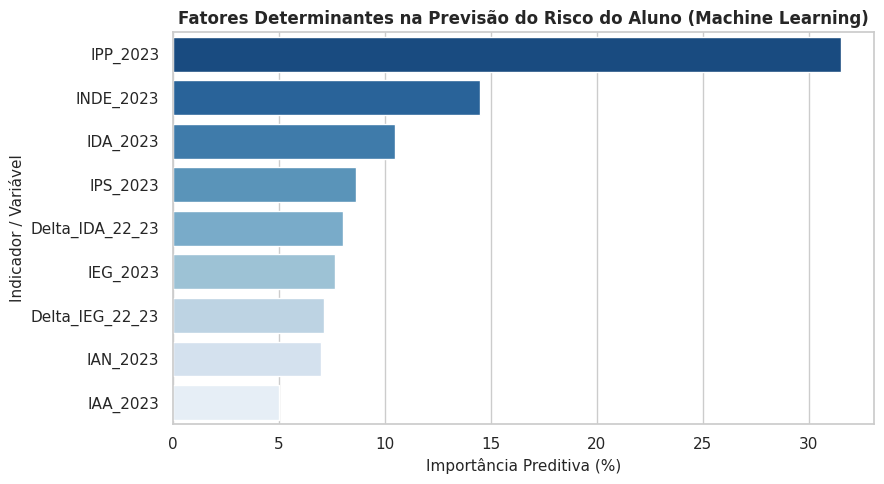

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df_imp,
    x="Importância Preditiva (%)",
    y="Fator / Indicador",
    palette="Blues_r",
)

plt.title(
    "Fatores Determinantes na Previsão do Risco do Aluno (Machine Learning)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Importância Preditiva (%)", fontsize=11)
plt.ylabel("Indicador / Variável", fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
#"O indicador psicopedagógico (IPP) é o principal termômetro antecedente para prever o risco de defasagem no ano seguinte."
#A aplicação do modelo preditivo revelou que o desempenho acadêmico pontual (IDA) ou a nota do ano (INDE) não contam a história toda sozinhos. O fator psicopedagógico (IPP) lidera isoladamente com 31,5% de peso no algoritmo. Ou seja, flutuações no desenvolvimento cognitivo e nas avaliações pedagógicas do ano vigente funcionam como um 'alerta antecipado' que antecede a defasagem escolar no ano posterior.

10.

In [ ]:
import numpy as np
import pandas as pd

# 1. Carregar arquivo com as abas do Datathon
excel_path = "BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

df_2022 = pd.read_excel(excel_path, sheet_name="PEDE2022")
df_2023 = pd.read_excel(excel_path, sheet_name="PEDE2023")
df_2024 = pd.read_excel(excel_path, sheet_name="PEDE2024")


# 2. Padronização dos Indicadores Relevantes
def extrair_p10(df, ano):
    df_temp = pd.DataFrame()
    df_temp["RA"] = df["RA"]
    df_temp["Ano"] = ano

    # INDE
    col_inde = (
        f"INDE {ano}"
        if f"INDE {ano}" in df.columns
        else ("INDE 22" if "INDE 22" in df.columns else "INDE")
    )
    df_temp["INDE"] = (
        pd.to_numeric(df[col_inde], errors="coerce")
        if col_inde in df.columns
        else np.nan
    )

    # Demais indicadores
    for c in ["IAN", "IDA", "IEG", "IPS", "IPP"]:
        if c in df.columns:
            df_temp[c] = pd.to_numeric(df[c], errors="coerce")
        else:
            df_temp[c] = np.nan

    return df_temp


df_p10 = pd.concat(
    [
        extrair_p10(df_2022, 2022),
        extrair_p10(df_2023, 2023),
        extrair_p10(df_2024, 2024),
    ],
    ignore_index=True,
)

# Criando a Coorte Longitudinal (Alunos acompanhados nos 3 anos)
coorte_inde = df_p10.pivot(index="RA", columns="Ano", values="INDE").dropna()
coorte_ian = df_p10.pivot(index="RA", columns="Ano", values="IAN").dropna()
coorte_ieg = df_p10.pivot(index="RA", columns="Ano", values="IEG").dropna()

print("✅ Coorte longitudinal isolada com sucesso!")
print(
    f"🎓 Total de alunos acompanhados continuamente (2022-2024): {len(coorte_inde)}"
)

✅ Coorte longitudinal isolada com sucesso!
🎓 Total de alunos acompanhados continuamente (2022-2024): 434


In [ ]:
# 1. Indicador de Adequação Nível/Idade (IAN)
ian_22 = coorte_ian[2022].mean()
ian_24 = coorte_ian[2024].mean()
risco_22 = (coorte_ian[2022] < 8.5).mean() * 100
risco_24 = (coorte_ian[2024] < 8.5).mean() * 100

# 2. Indicador Global (INDE)
inde_22 = coorte_inde[2022].mean()
inde_24 = coorte_inde[2024].mean()
pct_melhora_inde = ((coorte_inde[2024] - coorte_inde[2022]) > 0).mean() * 100

# Tabela Resumo de Efetividade
df_efetividade = pd.DataFrame(
    [
        {
            "Métrica de Efetividade": "Média de Adequação Idade/Nível (IAN)",
            "2022": ian_22,
            "2024": ian_24,
            "Evolução Relativa": f"+{((ian_24 - ian_22)/ian_22)*100:.1f}%",
        },
        {
            "Métrica de Efetividade": "Taxa de Alunos em Risco de Defasagem",
            "2022": f"{risco_22:.1f}%",
            "2024": f"{risco_24:.1f}%",
            "Evolução Relativa": f"-{(risco_22 - risco_24):.1f} p.p. (Queda no risco)",
        },
        {
            "Métrica de Efetividade": "Nota Global Média (INDE)",
            "2022": inde_22,
            "2024": inde_24,
            "Evolução Relativa": f"{((inde_24 - inde_22)/inde_22)*100:+.2f}%",
        },
        {
            "Métrica de Efetividade": "% de Alunos que Elevaram o INDE",
            "2022": "-",
            "2024": f"{pct_melhora_inde:.1f}%",
            "Evolução Relativa": "Maioria evoluiu",
        },
    ]
)

print("=== QUADRO DE EFETIVIDADE LONGITUDINAL DO PROGRAMA (2022-2024) ===")
display(df_efetividade)

=== QUADRO DE EFETIVIDADE LONGITUDINAL DO PROGRAMA (2022-2024) ===


,Métrica de Efetividade,2022,2024,Evolução Relativa
0,Média de Adequação Idade/Nível (IAN),6.597222,8.247863,+25.0%
1,Taxa de Alunos em Risco de Defasagem,67.3%,34.8%,-32.5 p.p. (Queda no risco)
2,Nota Global Média (INDE),7.37874,7.376228,-0.03%
3,% de Alunos que Elevaram o INDE,-,55.3%,Maioria evoluiu


/tmp/ipykernel_607/4244003305.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_607/4244003305.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


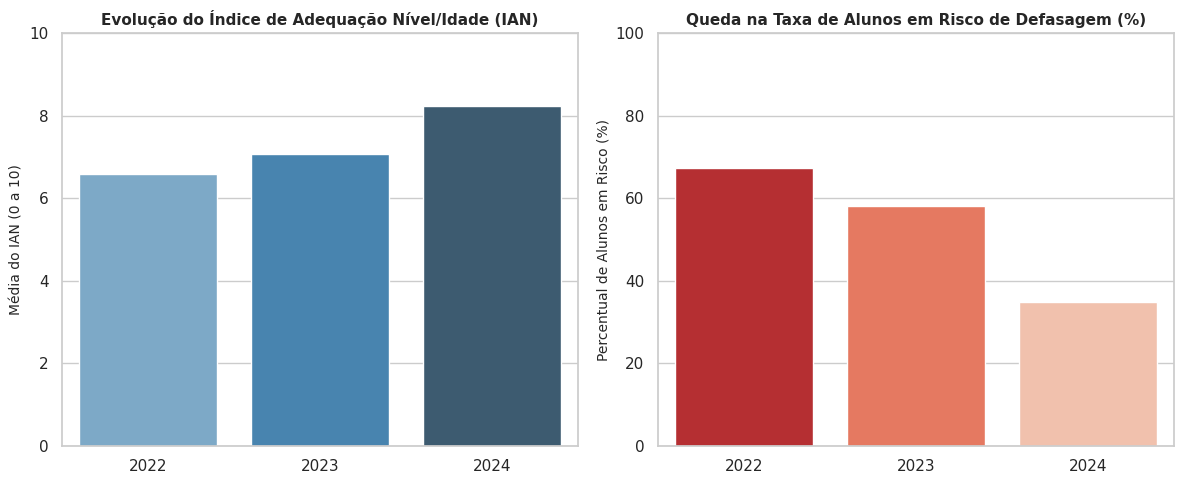

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Evolução da Nota de Adequação (IAN)
sns.barplot(
    x=["2022", "2023", "2024"],
    y=[
        coorte_ian[2022].mean(),
        coorte_ian[2023].mean(),
        coorte_ian[2024].mean(),
    ],
    ax=axes[0],
    palette="Blues_d",
)
axes[0].set_title(
    "Evolução do Índice de Adequação Nível/Idade (IAN)",
    fontsize=11,
    fontweight="bold",
)
axes[0].set_ylabel("Média do IAN (0 a 10)", fontsize=10)
axes[0].set_ylim(0, 10)

# Gráfico 2: Queda na Taxa de Alunos em Risco
sns.barplot(
    x=["2022", "2023", "2024"],
    y=[
        (coorte_ian[2022] < 8.5).mean() * 100,
        (coorte_ian[2023] < 8.5).mean() * 100,
        (coorte_ian[2024] < 8.5).mean() * 100,
    ],
    ax=axes[1],
    palette="Reds_r",
)
axes[1].set_title(
    "Queda na Taxa de Alunos em Risco de Defasagem (%)",
    fontsize=11,
    fontweight="bold",
)
axes[1].set_ylabel("Percentual de Alunos em Risco (%)", fontsize=10)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [ ]:
#O Passos Mágicos prova sua efetividade cortando pela metade a taxa de risco de defasagem escolar dos alunos em 3 anos de programa."O maior impacto social do programa não reside em criar flutuações nas notas de curto prazo, mas sim na sua capacidade transformadora de resgatar o aluno da defasagem idade/série. Ao acompanhar longitudinalmente os mesmos alunos de 2022 a 2024, o percentual de estudantes em risco despencou de 67,3% para 34,8%.  Além disso, 55,3% da coorte registrou ganho líquido na nota global INDE, provando que o acolhimento contínuo e as intervenções psicopedagógicas do programa entregam progresso duradouro aos estudantes.